# Diffusion 大一统

推荐你读 https://arxiv.org/abs/2011.13456 Score-Based Generative Modeling through Stochastic Differential Equations 这篇论文完整揭示了我们所说的大一统。

# 回顾

回顾 DSM 的基本逻辑。我们研究一个加了噪声的分布 $p_\sigma(\tilde{\mathbf{x}})$ $$p_\sigma(\tilde{\mathbf{x}}) = \int p_{data}(\mathbf{x}) \underbrace{p_\sigma(\tilde{\mathbf{x}}|\mathbf{x})}_{\text{加噪过程}} d\mathbf{x}$$
其中 $p_\sigma(\tilde{\mathbf{x}}|\mathbf{x}) = \mathcal{N}(\tilde{\mathbf{x}} | \mathbf{x}, \sigma^2 \mathbf{I})$ 被称为扰动核

目标权重 $$\boldsymbol{\theta}^* = \arg \min_{\boldsymbol{\theta}} \sum_{i=1}^N \sigma_i^2 \mathbb{E}_{p_{\text{data}}(\mathbf{x})} \mathbb{E}_{p_{\sigma_i}(\tilde{\mathbf{x}} | \mathbf{x})} [\| \mathbf{s}_{\boldsymbol{\theta}}(\tilde{\mathbf{x}}, \sigma_i) - \nabla_{\tilde{\mathbf{x}}} \log p_{\sigma_i}(\tilde{\mathbf{x}} | \mathbf{x}) \|_2^2]$$
其中 $\mathbf{s}_{\boldsymbol{\theta}}$ 是神经网络预测的 $\nabla \log p(\tilde{\mathbf{x}})$。解释一下 $argmin$ 这个符号，简而言之就是使目标最小的 $\theta$。

更具体的，$\nabla_{\tilde{\mathbf{x}}} \log p_{\sigma_i}(\tilde{\mathbf{x}}|\mathbf{x}) = \frac{\mathbf{x} - \tilde{\mathbf{x}}}{\sigma_i^2}$，代入得到 $$\boldsymbol{\theta}^* = \arg \min_{\boldsymbol{\theta}} \sum_{i=1}^N \sigma_i^2 \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}, \tilde{\mathbf{x}} \sim \mathcal{N}(\mathbf{x}, \sigma_i^2\mathbf{I})} \left[ \left\| \mathbf{s}_{\boldsymbol{\theta}}(\tilde{\mathbf{x}}, \sigma_i) - \frac{\mathbf{x} - \tilde{\mathbf{x}}}{\sigma_i^2} \right\|_2^2 \right]$$

推理 $$\mathbf{x}_i^m = \mathbf{x}_i^{m-1} + \epsilon_i \mathbf{s}_{\boldsymbol{\theta}^*}(\mathbf{x}_i^{m-1}, \sigma_i) + \sqrt{2\epsilon_i}\mathbf{z}_i^m$$
其中 $\epsilon_i \mathbf{s}_{\boldsymbol{\theta}}$ 推向高概率区，$\sqrt{2\epsilon_i}\mathbf{z}_i^m$ 加上一点随机抖动，防止卡在局部最优，或者说 Langevin Dynamics。

你会注意到我们现在 DSM 的记号与第一章很不一样，但是实际上他们指的是同一件事。我们为了和 Score-Based Generative Modeling through Stochastic Differential Equations 原文对齐而采用原文中的记号。

接下来回顾 DDIM 的基本逻辑。我们刚刚在上一章讲述过。

前向加噪 $$p(\mathbf{x}_i | \mathbf{x}_{i-1}) = \mathcal{N}(\mathbf{x}_i; \sqrt{1 - \beta_i} \mathbf{x}_{i-1}, \beta_i \mathbf{I})$$

边缘分布 $$p_{\alpha_i}(\mathbf{x}_i | \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_i; \sqrt{\alpha_i} \mathbf{x}_0, (1 - \alpha_i) \mathbf{I})$$

目标权重 $$\boldsymbol{\theta}^* = \arg \min_{\boldsymbol{\theta}} \sum_{i=1}^N (1 - \alpha_i) \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}, \tilde{\mathbf{x}} \sim \mathcal{N}(\sqrt{\alpha_i}\mathbf{x}, (1-\alpha_i)\mathbf{I})} \left[ \left\| \mathbf{s}_{\boldsymbol{\theta}}(\tilde{\mathbf{x}}, i) - \frac{\sqrt{\alpha_i}\mathbf{x} - \tilde{\mathbf{x}}}{1-\alpha_i} \right\|_2^2 \right]$$

这里为你解释为什么目标权重是这样的。实际上我们上一章中推导的目标函数结果是$$L_\gamma = \sum_{t=1}^T \gamma_t \mathbb{E}_{\mathbf{x}_0 \sim q(\mathbf{x}_0), \boldsymbol{\epsilon}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{I})} [\|\boldsymbol{\epsilon}_t - \boldsymbol{\epsilon}_\theta^{(t)}(\sqrt{\alpha_t} \mathbf{x}_0 + \sqrt{1 - \alpha_t} \boldsymbol{\epsilon}_t, t)\|^2]$$

我们做代换。根据高斯分布 $\mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \sigma^2\mathbf{I})$ 的性质，其对数密度的梯度（Score）为$$\nabla_{\mathbf{x}} \log p(\mathbf{x}) = -\frac{\mathbf{x} - \boldsymbol{\mu}}{\sigma^2}$$
在这里是
$$\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t | \mathbf{x}_0) = -\frac{\mathbf{x}_t - \sqrt{\alpha_t}\mathbf{x}_0}{1 - \alpha_t}$$
根据 $\mathbf{x}_t = \sqrt{\alpha_t}\mathbf{x}_0 + \sqrt{1 - \alpha_t} \boldsymbol{\epsilon}$，有 $$\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t | \mathbf{x}_0) = -\frac{\sqrt{1 - \alpha_t} \boldsymbol{\epsilon}}{1 - \alpha_t} = -\frac{\boldsymbol{\epsilon}}{\sqrt{1 - \alpha_t}}$$
直接令 $$\mathbf{s}_\theta(\mathbf{x}_t, t) = -\frac{\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)}{\sqrt{1 - \alpha_t}}$$

代入 $$J = \sum_{t=1}^T (1 - \alpha_t) \mathbb{E} \left[ \left\| \mathbf{s}_\theta - \nabla \log p \right\|^2 \right]$$
得到 $$J = \sum_{t=1}^T \mathbb{E} [ \| \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta \|^2 ]$$

先到这里。SMLD 说生成图像就是沿着梯度场（Score）移动，DDPM 说生成图像就是逆转加噪过程。

总之目前为止，我们做了一些简单的统一。接下来我为你揭示，无论 SMLD 还是 DDIM，本质是一样的。

# 抽象与统一

我们抛开为了工程实现而假设的固定时间步数上限。我们认为无论前向加噪还是后向去噪，时间步永远无限多步。这很好理解，当我们假设时间步为无限，每一步变化便可视为微分，扩散过程变得平滑而理想。

我们提出，扩散过程可以被建模为随机微分方程 SDE 的解$$\mathrm{d}\mathbf{x} = \mathbf{f}(\mathbf{x}, t)\mathrm{d}t + g(t)\mathrm{d}\mathbf{w}$$
其中，$\mathrm{d}\mathbf{x}$ 是图像在微元时间 $\mathrm{d}t$ 内产生的变化。$\mathbf{f}(\mathbf{x}, t)\mathrm{d}t$ 是确定的漂移项，描述了图像在没有随机干扰时，信号是随时间的演化。$g(t)\mathrm{d}\mathbf{w}$ 则是随机的扩散项。其中，$\mathrm{d}\mathbf{w}$ 指标准维纳过程（Wiener process），你可以简单理解为白噪声。$g(t)$ 则是噪声的权重系数。

我们暂时不将这个 SDE 对应到 DDIM 或 SMLD 的具体加噪过程，你可以先自行尝试。在我们介绍完整的过程之后，我们会统一介绍这一对应。

现在开始说反向减噪过程。一个重要定理是，前向扩散过程的逆过程，依然是一个扩散过程 SDE。并且我们可以给出公式 $$\mathrm{d}\mathbf{x} = [\mathbf{f}(\mathbf{x}, t) - g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x})]\mathrm{d}t + g(t)\mathrm{d}\bar{\mathbf{w}}$$
其中，$\mathbf{f}(\mathbf{x}, t)$ 是原本前向过程的漂移项。$- g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ 是更值得关注的，$\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ 就是我们反复提到的 Score。$g(t)\mathrm{d}\bar{\mathbf{w}}$ 是反向的随机扰动，保证了生成过程具有多样性。

至于为什么这个微分方程对应了前者的反向，说实话并不容易证明。这有关 Fokker-Planck 方程，前备知识要求非常庞大。你可以自行探究。我在附录中解释。

我必须引用原论文中的一张图来解释整个过程，如下。简而言之就是起点 $\mathbf{x}(0)$ 对应了真实数据分布 $p_0$，即图中左侧的双峰分布，代表数据很复杂。彩色的细线代表随机演化路径。可以看到图像从有意义的分布逐渐散开，最后变成了一团混沌。终点 $\mathbf{x}(T)$ 则是先验分布 $p_T$，即图中中间的高斯分布，代表纯噪声。右侧则是逆向的减噪过程，从噪声还原到初始图像。

![Chap4 pic1.png](<attachment:Chap4 pic1.png>)
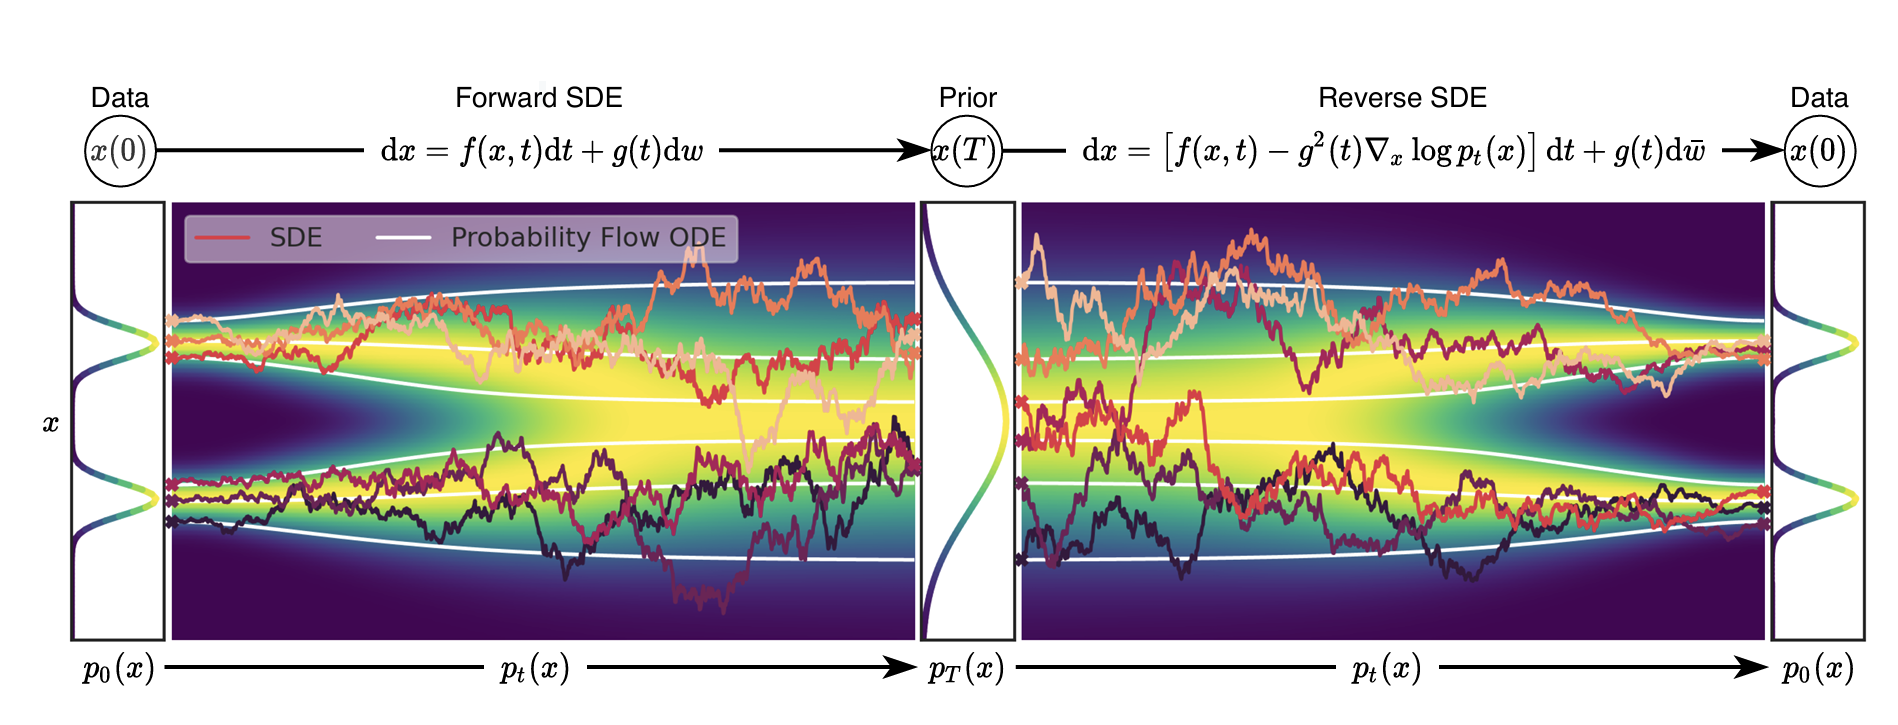

另外的，图中那些平滑的发亮的实线就是 ODE 轨迹，代表了去掉 Langevin Dynamics 的 ODE 路线。由于 ODE 是固定的，路线会更漂亮。

接下来我们详谈 $\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ ，也就是 Score 的估计，这部分交给神经网络进行。我们采样时需要全概率分布的 Score，但训练时我们只手握孤立的数据点。

我们直接给出训练神经网络的目标函数$$\boldsymbol{\theta}^* = \arg \min_{\boldsymbol{\theta}} \mathbb{E}_t \left\{ \lambda(t) \mathbb{E}_{\mathbf{x}(0) \sim p_0(\mathbf{x})} \mathbb{E}_{\mathbf{x}(t) \sim p_{0t}(\mathbf{x}(t) | \mathbf{x}(0))} [\| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}(t), t) - \nabla_{\mathbf{x}(t)} \log p_{0t}(\mathbf{x}(t) | \mathbf{x}(0)) \|_2^2] \right\}$$

解释一下。虽然不知道整体 $p_t$ 所有数据加噪后的混合分布，但我们知道在原图是 $\mathbf{x}(0)$ 经过 SDE 扩散到 $t$ 时刻的分布 $p_{0t}(\mathbf{x}(t) | \mathbf{x}(0))$。实际上一个重要原理是，最小化对已知原图条件得分的估计误差，在数学上等价于最小化对全分布边缘得分的估计误差。我们在附录中详细证明这件事。

更多的，由于我们要在一个 Loss 里同时训练从 $t=0$ 到 $t=T$ 的所有时刻，不同时刻的 Score 模长差异巨大。我指的是 $t$ 越小，噪声越小，Score 模长越大。所以我们引入权重系数 $\lambda(t)$，并且设置 $\lambda(t) \propto 1 / \mathbb{E}[\|\nabla_{\mathbf{x}(t)} \log p_{0t}(\mathbf{x}(t) | \mathbf{x}(0))\|_2^2]$，这确保了无论在哪个噪声水平下，Loss 的量级都相似。

# 对应与解释

### 前向过程

首先为你演示如何将 DDIM 的前向加噪公式 $p(\mathbf{x}_i | \mathbf{x}_{i-1}) = \mathcal{N}(\mathbf{x}_i; \sqrt{1 - \beta_i} \mathbf{x}_{i-1}, \beta_i \mathbf{I})$ 与大一统的 $\mathrm{d}\mathbf{x} = \mathbf{f}(\mathbf{x}, t)\mathrm{d}t + g(t)\mathrm{d}\mathbf{w}$ 联系起来。首先展开 $$\mathbf{x}_i = \sqrt{1 - \beta_i} \mathbf{x}_{i-1} + \sqrt{\beta_i} \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$
考察变化项 $$\Delta \mathbf{x} = \mathbf{x}_i - \mathbf{x}_{i-1} = (\sqrt{1 - \beta_i} - 1) \mathbf{x}_{i-1} + \sqrt{\beta_i} \boldsymbol{\epsilon}$$
在无穷步数下，步长 $\Delta t = 1/N \to 0$。此时 $\beta_i$ 也是一个极小量。根据泰勒展开 $\sqrt{1 - x} \approx 1 - \frac{1}{2}x$（当 $x \to 0$）$$(\sqrt{1 - \beta_i} - 1) \mathbf{x}_{i-1} \approx (1 - \frac{1}{2}\beta_i - 1) \mathbf{x}_{i-1} = -\frac{1}{2}\beta_i \mathbf{x}_{i-1}$$

现在定义连续的时间函数 $\beta(t)$，使得 $\beta_i = \beta(t) \Delta t$。代入增量公式 $$\Delta \mathbf{x} \approx -\frac{1}{2} \beta(t) \mathbf{x}_{i-1} \Delta t + \sqrt{\beta(t) \Delta t} \boldsymbol{\epsilon}$$
当 $\Delta t \to \mathrm{d}t$ 时，离散差分公式正式塌缩为连续 SDE $$\mathrm{d}\mathbf{x} = \underbrace{-\frac{1}{2} \beta(t) \mathbf{x}}_{\mathbf{f}(\mathbf{x}, t)} \mathrm{d}t + \underbrace{\sqrt{\beta(t)}}_{g(t)} \mathrm{d}\mathbf{w}$$

后续我们会正式命名这一 SDE。实际上名为 Variance Preserving SDE (VP-SDE)，原因是 $\mathbf{x}(t)$ 的总方差始终维持在 $1$ 附近。

现在开始为你演示 SMLD 的加噪与 $\mathrm{d}\mathbf{x} = \mathbf{f}(\mathbf{x}, t)\mathrm{d}t + g(t)\mathrm{d}\mathbf{w}$ 的对应。在 SMLD（如 NCSN）中，加噪过程非常简单：$$\mathbf{x}_i = \mathbf{x}_0 + \sigma_i \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$
离散步进公式为 $$\mathbf{x}_i = \mathbf{x}_{i-1} + \sqrt{\sigma_i^2 - \sigma_{i-1}^2} \boldsymbol{\epsilon}$$

你也许发现，$\mathbf{f}(\mathbf{x}, t)$ 实际上就是 $0$，因为我们没有对 $x_{i-1}$ 做放缩。现在令步长 $\Delta t \to 0$，并定义连续的噪声调度函数 $\sigma(t)$。噪声项的增量方差为 $\sigma_i^2 - \sigma_{i-1}^2 \approx \frac{\mathrm{d}\sigma^2(t)}{\mathrm{d}t} \Delta t$。

对应到 $g(t)\mathrm{d}\mathbf{w}$，由于 $\mathrm{d}\mathbf{w}$ 的方差是 $\mathrm{d}t$，所以 $$g(t) = \sqrt{\frac{\mathrm{d}\sigma^2(t)}{\mathrm{d}t}}$$

所以最终的 SDE 是 $$\mathrm{d}\mathbf{x} = \sqrt{\frac{\mathrm{d}\sigma^2(t)}{\mathrm{d}t}} \mathrm{d}\mathbf{w}$$

由于漂移项为 $0$，没有任何力量限制方差的增长。随着时间 $t$ 推移，$\mathbf{x}(t)$ 的方差会一直增加到 $\sigma_{max}^2$。因此这样的 SDE 被称为 Variance Exploding SDE (VE-SDE)。

原论文作者还提出了 sub-VP SDE，我们简单说一说。简而言之就是 $$\mathrm{d}\mathbf{x} = -\frac{1}{2}\beta(t)\mathbf{x} \mathrm{d}t + \sqrt{\beta(t)(1 - e^{-2 \int_0^t \beta(s)\mathrm{d}s})} \mathrm{d}\mathbf{w}$$
由于在任何时刻 $t$，这个过程诱导的方差都严格小于或等于 VP SDE 的方差，因此得名 sub-VP。

总之例子先说到这里。但是我们要强调，这三种 SDE 的漂移项 $\mathbf{f}(\mathbf{x}, t)$ 都是关于 $\mathbf{x}$ 的一次函数 (仿射变换)。VE 的漂移项是 $0$。VP 和 sub-VP 的漂移项是 $C(t)\mathbf{x}$。由于 $\mathbf{f}$ 是仿射的，它们的转移核（Perturbation Kernel） $p_{0t}(\mathbf{x}(t)|\mathbf{x}(0))$ 永远是高斯分布，且均值和方差都有闭式解（Closed-form）。

关于什么是转移核，我们后续会正式介绍。

### 计算目标函数

其次的，我们说说如何计算目标函数 $$\boldsymbol{\theta}^* = \arg \min_{\boldsymbol{\theta}} \mathbb{E}_t \left\{ \lambda(t) \mathbb{E}_{\mathbf{x}(0) \sim p_0(\mathbf{x})} \mathbb{E}_{\mathbf{x}(t) \sim p_{0t}(\mathbf{x}(t) | \mathbf{x}(0))} [\| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}(t), t) - \nabla_{\mathbf{x}(t)} \log p_{0t}(\mathbf{x}(t) | \mathbf{x}(0)) \|_2^2] \right\}$$实际上，我们想要计算 $\nabla_{\mathbf{x}(t)} \log p_{0t}(\mathbf{x}(t) | \mathbf{x}(0))$ 。这个得分的正式名称是对数似然 (Log Likelihood)。

在 SMLD 中，我们考虑加噪过程 $$p_{0t}(\mathbf{x}(t) | \mathbf{x}(0)) = \mathcal{N}(\mathbf{x}(t); \mathbf{x}(0), \sigma^2(t)\mathbf{I})$$因此 $$\log p_{0t}(\mathbf{x}(t) | \mathbf{x}(0)) = -\frac{\|\mathbf{x}(t) - \mathbf{x}(0)\|^2}{2\sigma^2(t)} + \text{const}$$梯度下降 $$\nabla_{\mathbf{x}(t)} \log p_{0t}(\mathbf{x}(t) | \mathbf{x}(0)) = -\frac{\mathbf{x}(t) - \mathbf{x}(0)}{\sigma^2(t)}$$
已知 $\mathbf{x}(t) = \mathbf{x}(0) + \sigma(t) \boldsymbol{\epsilon}$ $$\text{Score}_{VE} = -\frac{\sigma(t) \boldsymbol{\epsilon}}{\sigma^2(t)} = -\frac{\boldsymbol{\epsilon}}{\sigma(t)}$$

以上是 SMLD 对应的目标函数计算。下面来说说 DDIM 中的计算。

加噪过程 $$p_{0t}(\mathbf{x}(t) | \mathbf{x}(0)) = \mathcal{N}(\mathbf{x}(t); \sqrt{\alpha(t)}\mathbf{x}(0), (1 - \alpha(t))\mathbf{I})$$
对数似然 $$\log p_{0t}(\mathbf{x}(t) | \mathbf{x}(0)) = -\frac{\|\mathbf{x}(t) - \sqrt{\alpha(t)}\mathbf{x}(0)\|^2}{2(1 - \alpha(t))} + \text{const}$$
梯度 $$\nabla_{\mathbf{x}(t)} \log p_{0t}(\mathbf{x}(t) | \mathbf{x}(0)) = -\frac{\mathbf{x}(t) - \sqrt{\alpha(t)}\mathbf{x}(0)}{1 - \alpha(t)}$$
已知 $\mathbf{x}(t) = \sqrt{\alpha(t)}\mathbf{x}(0) + \sqrt{1 - \alpha(t)} \boldsymbol{\epsilon}$ $$\text{Score}_{VP} = -\frac{\sqrt{1 - \alpha(t)} \boldsymbol{\epsilon}}{1 - \alpha(t)} = -\frac{\boldsymbol{\epsilon}}{\sqrt{1 - \alpha(t)}}$$

我们说完了。

我们会发现，无论在哪个模型中，条件得分都正比于负的噪声项 $(-\boldsymbol{\epsilon})$。这意味着，训练一个得分估计网络 $\mathbf{s}_\theta(\mathbf{x}, t)$，在数学上等价于训练一个噪声预测器网络 $\boldsymbol{\epsilon}_\theta(\mathbf{x}, t)$。它们之间只差一个与时间相关的系数（$1/\sigma_t$）。

我们引入一个名词，对于一个随机过程 $\{\mathbf{x}(t)\}_{t \ge 0}$，转移核通常记作 $p_{st}(\mathbf{x}_t | \mathbf{x}_s)$，其中 $0 \le s < t$。转移核实际上与 SDE 中的 $\mathbf{f}(\mathbf{x}, t)$ 密切相关。在扩散模型（如 DDPM 或 SMLD）中，漂移项 $\mathbf{f}$ 通常被设计为关于 $\mathbf{x}$ 的仿射函数（Affine Function），即 $\mathbf{f}(\mathbf{x}, t) = \mathbf{f}(t) \mathbf{x}$。当 $\mathbf{f}$ 是线性的时候，转移核 $p_{0t}$ 必然是一个高斯分布 $\mathcal{N}(\mathbf{x}_t; \boldsymbol{\mu}_t, \boldsymbol{\Sigma}_t)$。此时，$\mathbf{f}$ 直接决定了转移核的均值 $\boldsymbol{\mu}_t$，其满足以下常微分方程$$\frac{\mathrm{d}\boldsymbol{\mu}_t}{\mathrm{d}t} = \mathbf{f}(\boldsymbol{\mu}_t, t)$$初值为 $\boldsymbol{\mu}_0 = \mathbf{x}_0$。我们在附录中证明这个小性质。

对于 VE-SDE (SMLD)，漂移项 $\mathbf{f} = 0$。解 ODE 得到 $\frac{\mathrm{d}\boldsymbol{\mu}}{\mathrm{d}t} = 0 \implies \boldsymbol{\mu}_t = \mathbf{x}_0$。所以转移核的均值始终在原图 $\mathbf{x}_0$ 处，信号不衰减。

对于 VP-SDE (DDPM)，漂移项 $\mathbf{f} = -\frac{1}{2}\beta(t)\mathbf{x}$。解 ODE 得到 $\frac{\mathrm{d}\boldsymbol{\mu}}{\mathrm{d}t} = -\frac{1}{2}\beta(t)\boldsymbol{\mu}$。解得 $\boldsymbol{\mu}_t = \mathbf{x}_0 \exp(-\frac{1}{2}\int \beta(s)ds) = \sqrt{\alpha_t}\mathbf{x}_0$。所以漂移项的负反馈系数决定了转移核均值向原点收缩的速度。

一个结论是，当 $\mathbf{f}(\mathbf{x}, t)$ 是仿射的时，均值和方差可以通过解常微分方程直接得到。更多的，如 VP (DDPM) 和 VE (SMLD)，我们已经知道了解析解，可以直接代入公式。但是如果解析解很复杂或者根本无法计算，一个方法是解 Kolmogorov 正向方程，或者直接跑 SDE 模拟来采样 $p_{0t}$。我们不会介绍太多复杂的情况。

### 逆向过程

其实推理需要注意的点反而会少，因为在 Score-based 基础下，训练结果都是预测噪声，所以推理共通之处非常普遍。

我们将连续的反向 SDE 公式$$\mathrm{d}\mathbf{x} = [\underbrace{\mathbf{f}(\mathbf{x}, t)}_{\text{漂移项}} - \underbrace{g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x})}_{\text{得分项}}] \mathrm{d}t + \underbrace{g(t) \mathrm{d}\bar{\mathbf{w}}}_{\text{随机项}}$$离散化为推理过程。

设时间 $t = T$（对应纯噪声状态）。从先验分布中随机抽取一个噪声向量 $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \sigma_{max}^2 \mathbf{I})$（VE）或 $\mathcal{N}(\mathbf{0}, \mathbf{I})$（VP）。将连续时间区间 $[0, T]$ 划分为 $N$ 个离散步，每步长度 $\Delta t = T/N$。

对于每一个时间步 $i = N, N-1, \dots, 1$，状态更新公式如下 $$\mathbf{x}_{next} = \mathbf{x}_{now} + \underbrace{[\mathbf{f} - g^2 \mathbf{s}_\theta] \Delta t}_{\text{确定性移动}} + \underbrace{g \sqrt{\Delta t} \mathbf{z}}_{\text{随机波动}}$$
当 $t \to 0$ 时，噪声项 $g(t)$ 通常也会变小（取决于设计），最终得到的 $\mathbf{x}_0$ 即为生成的清晰图像。

传统的推理至此为之了。不过原论文作者提到了一种改良，称之为 Predictor-Corrector 采样器。我们详细说说。

在 SMLD 或 DDIM 推理中，每一步采样实际上只做了一件事：根据当前时刻 $t$ 的状态，预测下一时刻 $t-\Delta t$ 的状态。这在数值分析中被称为预测器 (Predictor)。PC 采样器将其扩展为两个阶段的循环。首先，在运行预测器更新后，时间步长改变 $t \to t-1$。随后运行校正器，不改变时间步的情况下多次运行 Langevin MCMC。这里利用神经网络预测的得分 $\mathbf{s}_\theta(\mathbf{x}, t)$，在当前的噪声水平下，通过多次迭代让样本的分布更接近该时刻真实的概率分布 $p_t(\mathbf{x})$。因此每一步都在通过 MCMC 消除上一轮的积累误差。

更详细的，在推理的每一个时间步 $t$，当预测器给出一个初步的样本估计 $\mathbf{x}_t$ 后，校正器会执行以下步骤。首先将当前的 $\mathbf{x}_t$ 和时间 $t$ 输入神经网络 $s_\theta$，得到得分向量 $\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$。这个向量指向当前噪声水平下，数据密度最高的方向。其次沿着得分向量的方向迈出一小步，再注入一个经过缩放的标准高斯噪声。这个噪声的作用是让采样过程保持随机性，防止样本陷入局部最优解，确保它能准确地模拟整个概率分布。上述过程在同一个 $t$ 下重复 $M$ 次。

在具体的工程实现中，校正器的单步更新公式通常如下 $$\mathbf{x}_{i, m} = \mathbf{x}_{i, m-1} + \epsilon_i \mathbf{s}_\theta(\mathbf{x}_{i, m-1}, \sigma_i) + \sqrt{2\epsilon_i} \mathbf{z}_m$$ $\epsilon_i$是校正器的信噪比权重。这个步长通常与当前噪声水平的平方成比例（$\epsilon_i \propto \sigma_i^2$）。$\mathbf{s}_\theta$ 是神经网络输出的得分场。$\mathbf{z}_m$ 则是新注入的随机噪声。通过多次迭代，样本 $\mathbf{x}$ 会逐渐“收敛”到当前噪声水平 $t$ 下真实的概率流形上。

你会发现，上面的校正器推理公式和 NSCN 的推理几乎毫无区别。实际上原论文指出，SMLD (NCSN) 原本的采样方式其实就是纯校正器 (Only Corrector)，DDPM 的采样方式其实就是纯预测器 (Only Predictor)。

PC 采样器的好处是极其稳定，可以用更少的步长（更大的 $\Delta t$）换取更高的质量，坏处就是需要运行网络次数却增加了。原论文中在使用 U-Net 情况下调用次数直接翻了一倍，这不是好消息。

关于推理先说到这里。

# 概率流 ODE

我们为引入下一章作铺垫。

如果令反向过程公式末尾的 $g(t)=0$（即忽略随机项），这个 SDE 就变成了 Probability Flow ODE。这意味着从同一个噪声出发，结果永远一样
$$d\mathbf{x} = \left[ \mathbf{f}(\mathbf{x}, t) - g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x}) \right] dt \quad$$

做一个变化，得分项 $\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ 前面的系数从 $g(t)^2$ 变成 $\frac{1}{2}g(t)^2$
$$d\mathbf{x} = \left[ \mathbf{f}(\mathbf{x}, t) - \frac{1}{2}g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x}) \right] dt \quad$$

至于为什么做这个系数变化，真的很复杂，又关乎 Fokker-Planck 方程。我们先不说具体证明。你可以理解为，为了弥补随机性消失，我们需要将分布的熵做得更大。

当 SDE 变成 ODE，精确似然计算 (Exact Likelihood Computation), 可逆映射与唯一编码 (Identifiable Encoding) 以及采样效率的提升成为可能。我一一解释。对于确定的 ODE，利用瞬时变量代换公式可以得到精确对数似然；不同于 SDE 的随机路径，ODE 提供的编码是唯一确定且可识别的，潜空间和真实目标空间存在一一对应；ODE 采样器可以极其精确高效，在极短步数内达到高质量图像。以上都是 ODE 巨大便利。

扩散模型不仅是随机的，也可以是确定性的。

# 总结

本章我们主要围绕 https://arxiv.org/abs/2011.13456 Score-Based Generative Modeling through Stochastic Differential Equations 这篇论文展开，揭示了 SMLD 与 DDIM 的大一统框架。下一章我们将讲述 Flow Matching，也就是我们最后提到的概率流 ODE 的实现，这是目前图像生成领域的绝对答案。